# <u>(Multivariate) Polynomial Regression</u>

### Prerequisites:
* <a href="../1.Simple%20Linear%20Regression/Simple%20Linear%20Regression.ipynb">Check out the notebook on Simple Linear Regression</a>
* <a href="../2.Multiple%20linear%20Regression/Multiple%20linear%20Regression.ipynb">Check out the notebook on Multiple Linear Regression</a>

## Topics

* [0. Review Multiple linear Regression setup](#review)
* [1. Polynomial Regression](#poly)
    * [1.1 Setup](#setup1)
    * [1.2 Basis function expansion](#expnsion1)
    * [1.3 Examples](#example1)

* [2. Multivariate Polynomial Regression](#multpoly)
    * [2.1 Setup](#setup2)
    * [2.2 Basis function expansion](#expnsion2)
    * [2.3 Examples](#example2)



In [ ]:
import numpy as np # for matrix operations and random number generation
from matplotlib import pyplot as plt # for 2 dimensional plotting
import plotly.graph_objects as go # interactive 3D plots but more complex
import plotly.express as px # also for interactive 3D plots but more simple
from sklearn.preprocessing import PolynomialFeatures # preprocessing for Polynomial regression
from math import comb # for binomial coefficient
from sklearn.linear_model import LinearRegression # perform OLS
import statsmodels.api as sm # for statistical outputs 
print("Setup complete")

<a class="anchor" id="review"></a>
## 0. Review Multiple linear Regression setup

Recall the Multiple linear Regression model:

$$
y^{(i)} =  \theta_0 + \left(\sum_{j=1}^p \theta_j x_j^{(i)}\right) + \varepsilon^{(i)} , \hspace{2 mm} i = 1,...,n
$$

This is actually just a special case of a more general model 

$$
y^{(i)} =  \theta_0 + \left(\sum_{j=1}^p \theta_j \phi_j(x_j^{(i)})\right) + \varepsilon^{(i)} , \hspace{2 mm} i = 1,...,n
$$

where $\phi_j = \text{id}_ x : x \mapsto x \forall j$. Since this model is still <u>linear in parameters $\theta$</u> we can still use the same design matrix $X$ and the OLS solution:

$$
y = \theta_0 \cdot 1_n + \left(\sum_{j=1}^p \theta_j \cdot \phi_j(x_j)\right) + \varepsilon \hspace{1 mm} \text{ with } \phi_j(x_j)=\phi(\begin{pmatrix} x_j^{(1)} \\ \vdots \\ x_j^{(n)} \end{pmatrix})=\begin{pmatrix} \phi(x_j^{(1)}) \\ \vdots \\ \phi(x_j^{(n)}) \end{pmatrix}
$$

$$
\Leftrightarrow
y = X\theta + \varepsilon
$$

where:

$$
y =
\begin{pmatrix}
y^{(1)} \\
y^{(2)} \\
\vdots \\
y^{(n)}
\end{pmatrix}, 

\quad

X =
\begin{pmatrix}
1 & \phi(x_1^{(1)}) & \ldots & \phi(x_p^{(1)}) \\
1 & \phi(x_1^{(2)}) & \ldots & \phi(x_p^{(2)}) \\
\vdots & \vdots & \ddots & \vdots \\
1 & \phi(x_1^{(n)}) & \ldots & \phi(x_p^{(n)})
\end{pmatrix},

\quad

\theta =
\begin{pmatrix}
\theta_0 \\
\theta_1 \\
\vdots \\
\theta_p
\end{pmatrix},

\quad

\varepsilon=
\begin{pmatrix}
\varepsilon^{(1)} \\
\varepsilon^{(2)} \\
\vdots \\
\varepsilon^{(n)}
\end{pmatrix}
$$


<a class="anchor" id="poly"></a>
## 1. Polynomial Regression


<a class="anchor" id="setup1"></a>
## 1.1 Setup

In this notebook, we first consider **Polynomial Regression**, where the goal is to model a nonlinear relationship between an input variable $x$ and a target variable $y$.

### Variables

* $x$ $-$ input feature  
* $y$ $-$ target variable  

We assume the following model:

$$
y^{(i)} = \sum_{k=0}^{d} \theta_k \, \phi_k(x^{(i)}) + \varepsilon^{(i)}
\hspace{2mm} \text{for } i = 1, \dots, n
$$

where $\varepsilon_i$ is an error term and $\phi_0(x) = x^0 = 1, \phi_k(x) = x^k$ for $k=1,...,d$ are **basis functions** that transform the input.

For **polynomial regression**, we choose the basis functions as

$$
\phi^{(d)}: \mathbb{R} \rightarrow \mathbb{R}^{d+1}, x \mapsto [\phi_0(x),\phi_1(x),\phi_2(x),...,\phi_d(x)]^\top=[x^0,x^1,x^2,...,x^d]^\top=[1,x,x^2,..,x^d]^\top
$$


The model learns a function of the form:

$$
\hat{y}^{(i)} =  \sum_{k=0}^{d} \hat{\theta}_k \phi_k(x^{(i)}) = \phi^{(d)}(x^{(i)})^\top \hat{\theta}
$$

where $\hat{\theta}=\begin{pmatrix} \hat{\theta}_0 \\ \hat{\theta}_1 \\ \vdots \\ \hat{\theta}_d \end{pmatrix} \in \mathbb{R}^{d+1}$

---

### Matrix formulation

Let

$$
y =
\begin{pmatrix}
y^{(1)} \\
y^{(2)} \\
\vdots \\
y^{(n)}
\end{pmatrix} \in \mathbb{R}^{n} , 
\quad
\theta =
\begin{pmatrix}
\theta_0 \\
\theta_1 \\
\vdots \\
\theta_d
\end{pmatrix} \in \mathbb{R}^{d+1},
\quad
\varepsilon =
\begin{pmatrix}
\varepsilon^{(1)} \\
\varepsilon^{(2)} \\
\vdots \\
\varepsilon^{(n)}
\end{pmatrix} \in \mathbb{R}^{n}
$$

The **design matrix** is given by:

$$
X =
\begin{pmatrix}
\phi^{(d)}(x^{(1)})^\top \\
\phi^{(d)}(x^{(2)})^\top \\
\vdots \\
\phi^{(d)}(x^{(n)})^\top \\
\end{pmatrix}
=
\begin{pmatrix}
(x^{(1)})^0 & (x^{(1)})^1 & (x^{(1)})^2 & \cdots & (x^{(1)})^d \\
(x^{(2)})^0 & (x^{(2)})^1 & (x^{(2)})^2 &\cdots & (x^{(2)})^d \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
(x^{(n)})^0 & (x^{(n)})^1 & (x^{(n)})^2 & \cdots & (x^{(n)})^d
\end{pmatrix}
=
\begin{pmatrix}
1 & x^{(1)} & (x^{(1)})^2 & \cdots & (x^{(1)})^d \\
1 & x^{(2)} & (x^{(2)})^2 &\cdots & (x^{(2)})^d \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
1 & x^{(n)} & (x^{(n)})^2 & \cdots & (x^{(n)})^d
\end{pmatrix}
$$

Then the model can be written compactly as:

$$
y = X \theta + \varepsilon
\quad \text{and} \quad
\hat{y} = X \hat{\theta}  
$$

or more precise

$$
\begin{pmatrix}
y^{(1)} \\
y^{(2)} \\
\vdots \\
y^{(n)}
\end{pmatrix} = 
\begin{pmatrix}
\phi^{(d)}(x^{(1)})^\top \theta \\
\phi^{(d)}(x^{(2)})^\top \theta \\
\vdots \\
\phi^{(d)}(x^{(n)})^\top \theta \\
\end{pmatrix}
 + 
\begin{pmatrix}
\varepsilon^{(1)} \\
\varepsilon^{(2)} \\
\vdots \\
\varepsilon^{(n)}
\end{pmatrix}
\quad \text{and} \quad
\begin{pmatrix}
\hat{y}^{(1)} \\
\hat{y}^{(2)} \\
\vdots \\
\hat{y}^{(n)}
\end{pmatrix} = 
\begin{pmatrix}
\phi^{(d)}(x^{(1)})^\top \hat{\theta} \\
\phi^{(d)}(x^{(2)})^\top \hat{\theta} \\
\vdots \\
\phi^{(d)}(x^{(n)})^\top \hat{\theta} \\
\end{pmatrix}  
$$




```python
# POLYNOMIAL FEATURES GUIDE

# --- SKLEARN: Polynomial Feature Expansion ---
from sklearn.preprocessing import PolynomialFeatures
import numpy as np

# Define transformer
# degree=d -> generate all polynomial combinations up to degree d
# interaction_only=False -> include powers like x^2, x^3 (not just interactions)
# include_bias=True -> include constant column (1)
# order='C' -> row-major order (default)
d = 3
poly = PolynomialFeatures(degree=d, interaction_only=False, include_bias=True, order='C')

# Example input (1 feature)
X = np.array([[2],
              [3],
              [4]])

# Fit (learn structure ONLY, no transformation yet)
poly.fit(X) # .fit() only takes argument with shape (n,m) but not (n,) so if X = np.array([2,3,4]) then we have to reshape to X.reshape(-1,1) 

# -------------------------
# Attributes after .fit()
# -------------------------
poly.n_input_features_in_ # number of original features (here: 1)
poly.n_output_features_ # number of generated features comb(p + degree, degree) Binomial coefficient with p = poly.n_input_features_in_
poly.powers_ # exponent combinations
poly.feature_names_in_ # only exists if input had column names
poly.get_feature_names_out() # readable feature names

# Example of what happens internally for ONE feature (degree=3):
# Input:
# X = [[x]]
#
# Output after transform:
# [1, x, x^2, x^3]
#
# Example:
# X = [[2]] -> [1, 2, 4, 8]


# Transform data
X_poly = poly.transform(X)

# Shortcut (fit + transform)
X_poly = poly.fit_transform(X)


# -------------------------
# Example with TWO features
# -------------------------

X2 = np.array([[2, 3]]) # x1=2, x2=3

poly2 = PolynomialFeatures(degree=2)
X2_poly = poly2.fit_transform(X2)

# Transformation explanation:
# Input:
# [x1, x2]
#
# Output:
# [1,
#  x1, x2,
#  x1^2, x1*x2, x2^2]
#
# Example:
# [2, 3] -> [1, 2, 3, 4, 6, 9]


# -------------------------
# Using with LinearRegression
# -------------------------
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_poly, y) # fit model on transformed data

# Predict on new data (must transform first!)
X_new = np.array([[5]])
X_new_poly = poly.transform(X_new)

y_pred = model.predict(X_new_poly)


# -------------------------
# Using with statsmodels (for statistical output)
# -------------------------
import statsmodels.api as sm

# Add constant manually if not included
X_sm = sm.add_constant(X_poly)

model_sm = sm.OLS(y, X_sm).fit()
# model_sm.summary()  # gives full statistical report


# -------------------------
# NUMPY: Polynomial Fitting
# -------------------------

x = np.array([1, 2, 3, 4])
y = np.array([1, 4, 9, 16])

# Fit polynomial of degree 2
coeffs = np.polyfit(x, y, deg=2)

# Convert to function-like object
p = np.poly1d(coeffs)

# Evaluate
p(5) # value at x=5

# Derivative and integral
p.deriv() # derivative polynomial
p.integ() # integral polynomial


# -------------------------
# NUMPY (NEW API - recommended)
# -------------------------
from numpy.polynomial import Polynomial

p2 = Polynomial.fit(x, y, deg=2)

p2(5) # evaluate



# KEY TAKEAWAYS

# PolynomialFeatures:
# - Expands features into polynomial + interaction terms
# - Does NOT fit a model, only transforms data
#
# Workflow:
# 1. poly.fit(X)         -> learn structure
# 2. poly.transform(X)   -> expand features
# 3. model.fit(X_poly,y) -> train model
#
# Always transform new data the same way before prediction!

```

<a class="anchor" id="expansion1"></a>
## 1.2 Basis function expansion

In [3]:
# Basis function expansion
def phi(x,d):
    """
    Maps scalar to polynomial features
    Input:
        x: one dimensional iterable and mutable and scriptable data type of length n
        d: number of polynomial features (max degree = d-1)
    Output:
        Phi: numpy array of shape (n,d)
    """
    #return np.array([[i**j for i in x] for j in range(0,d)]).T
    #return np.c_[ [np.asarray(x)**j for j in range(d)] ].T
    return np.column_stack([np.asarray(x)**j for j in range(d)])


# Example
x,x_ = [2,3,4,5,6,7,8,9,10], [2,3,4]
d_plus_1 = 3
print(f"phi^{d_plus_1-1}=\n{phi(x,d_plus_1)}\n")
print(f"phi^{d_plus_1-1}=\n{phi(x_,d_plus_1)}\n")


# Better version of basis function expansio
def Phi(x, d):
    """
    Maps scalar to polynomial features
    Input:
        x: one dimensional iterable and mutable and scriptable data type of length n
        d: number of polynomial features (max degree = d-1)
    Output:
        Phi: numpy array of shape (n,d)
    """
    x = np.asarray(x)
    return np.vstack([x**i for i in range(d)]).T

print(f"phi^{d_plus_1-1}=\n{Phi(x,d_plus_1)}\n")
print(f"phi^{d_plus_1-1}=\n{Phi(x_,d_plus_1)}\n")

phi^2=
[[  1   2   4]
 [  1   3   9]
 [  1   4  16]
 [  1   5  25]
 [  1   6  36]
 [  1   7  49]
 [  1   8  64]
 [  1   9  81]
 [  1  10 100]]

phi^2=
[[ 1  2  4]
 [ 1  3  9]
 [ 1  4 16]]

phi^2=
[[  1   2   4]
 [  1   3   9]
 [  1   4  16]
 [  1   5  25]
 [  1   6  36]
 [  1   7  49]
 [  1   8  64]
 [  1   9  81]
 [  1  10 100]]

phi^2=
[[ 1  2  4]
 [ 1  3  9]
 [ 1  4 16]]



<a class="anchor" id="example1"></a>
## 1.3 Examples

X_manual=
[[  1.           2.57998836   6.65633992  17.17327948]
 [  1.           4.8664804   23.68263147 115.25106185]
 [  1.           7.83071756  61.3201375  480.18067746]
 [  1.           9.22411667  85.08432833 784.82777126]
 [  1.           2.16729756   4.6971787   10.18018392]]

X_library=
[[  1.           2.57998836   6.65633992  17.17327948]
 [  1.           4.8664804   23.68263147 115.25106185]
 [  1.           7.83071756  61.3201375  480.18067746]
 [  1.           9.22411667  85.08432833 784.82777126]
 [  1.           2.16729756   4.6971787   10.18018392]]

Manual theta:
 [ 256.3641128  -249.27059667   60.59519792   -1.22138345]
Library theta:
 [ 256.3641128  -249.27059667   60.59519792   -1.22138345]


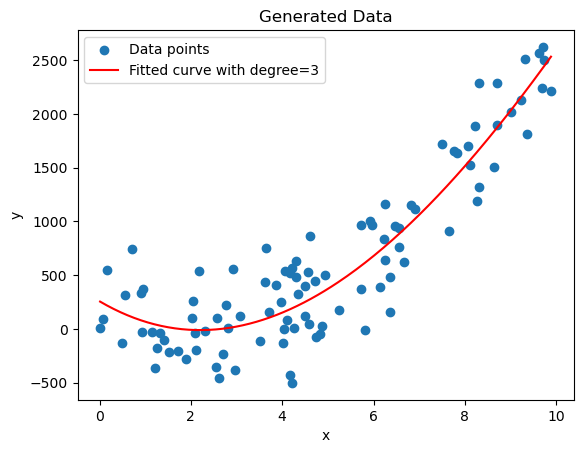

In [4]:
# Generate data
np.random.seed(1236)
n = 100
x=np.random.uniform(0,10,n)
error = np.random.normal(loc=0,scale=300,size=n)


# Cretae Design matrix manually
d=3
X_manual=Phi(x,d+1)
print(f"X_manual=\n{X_manual[:5,]}\n")
true_theta = np.random.uniform(0,4,d+1)
y = np.dot(X_manual, true_theta) + error


# Cretae Design matrix with library
poly=PolynomialFeatures(degree=d,include_bias=True)
X_library=poly.fit(x.reshape(-1,1))
X_library=poly.transform(x.reshape(-1,1))
print(f"X_library=\n{X_library[:5,]}\n")

# Plot data
plt.scatter(x, y,label="Data points")
plt.title("Generated Data")
plt.xlabel("x")
plt.ylabel("y")


# Compute coefficients manually (Normal Equation)
theta_manual = np.linalg.inv(X_manual.T @ X_manual) @ X_manual.T @ y
print("Manual theta:\n", theta_manual)

# Compute coefficients with library
model = LinearRegression(fit_intercept=False)
model.fit(X_library, y)
theta_library = model.coef_
print("Library theta:\n", theta_library)


# Make predictions
x_line = np.linspace(x.min(), x.max(), 200)
X_line = Phi(x_line, d+1)
y_hat = X_line @ theta_manual

plt.plot(x_line, y_hat, color="red", label=f"Fitted curve with degree={d}")
plt.legend()
plt.show()

In [5]:
# Function generating non linear data
def poly_sample(true_theta, n=100, seed=1435, noise_std=0.05):
    """
    Generate more complex nonlinear data using polynomial + sinusoidal terms
    Returns:
        x (n,), y (n,)
    """
    np.random.seed(seed)
    x = np.random.rand(n)

    # polynomial part
    X = Phi(x, len(true_theta))
    poly_part = X @ true_theta

    # extra nonlinear structure
    nonlinear_part = 0.3 * np.sin(5 * np.pi * x)

    true_y = poly_part + nonlinear_part
    y = true_y + noise_std * np.random.randn(n)
    return x, y


# Function to compute OLS
def poly_reg(x, y, d):
    """
    Fit polynomial regression of degree d+1 using OLS
    
    Returns:
        theta_hat (d+1,)
    """
    X = Phi(x, d)
    theta_hat = np.linalg.inv(X.T @ X) @ X.T @ y
    return theta_hat


# Make predictions
def predict(x, theta_hat):
    """
    Predict y using polynomial model and coefficients theta_hat
    Returns:
        y_hat (n,)
    """
    X = Phi(x, theta_hat.shape[0])
    y_hat = X @ theta_hat
    return y_hat


help(poly_sample) # acces docstrings
print("---------")
print(poly_sample.__doc__) # acces docstrings
print("---------")
#poly_sample?
#poly_sample?? # docstring and source code

Help on function poly_sample in module __main__:

poly_sample(true_theta, n=100, seed=1435, noise_std=0.05)
    Generate more complex nonlinear data using polynomial + sinusoidal terms
    Returns:
        x (n,), y (n,)

---------

Generate more complex nonlinear data using polynomial + sinusoidal terms
Returns:
    x (n,), y (n,)

---------



Degree d = 2
[-0.1899  2.5736]

Degree d = 6
[  0.7315  -7.5035  38.8952 -75.1333  69.4605 -23.5155]

Degree d = 11
[ 1.07260000e+00 -4.75144000e+01  9.62591900e+02 -8.70706470e+03
  4.25482242e+04 -1.25060367e+05  2.34534081e+05 -2.85710470e+05
  2.20288383e+05 -9.78864918e+04  1.90801448e+04]


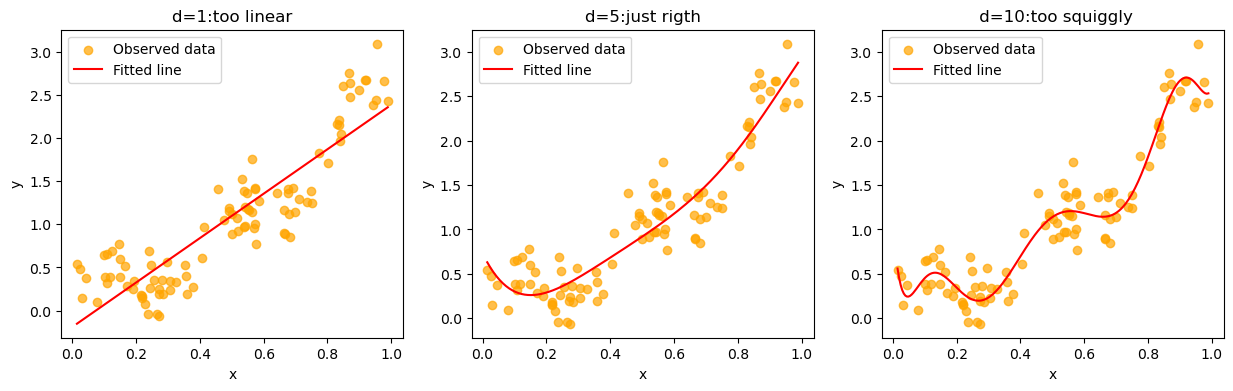

In [6]:
# sample data
x,y = poly_sample(np.array([0.2,0.5,2]),noise_std=0.20)

theta_hist=[] # history of estimated thetas

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15,4))

# iterate over axes and avoid axes[...]
for ax,i,title in zip(axes, [2,6,11], ["d=1:too linear", "d=5:just rigth", " d=10:too squiggly"]):
    
    # fit model
    theta_hat = poly_reg(x, y, i)

    theta_hist.append(theta_hat.copy())

    # predictions (sort x for a clean line)
    x_plot = np.linspace(x.min(), x.max(), 200)
    y_plot = predict(x_plot, theta_hat)

    # scatter plot of data
    ax.scatter(x, y, label="Observed data", alpha=0.7, color="orange") # alpha = 0.7 controls transparency of points

    # regression line
    ax.plot(x_plot, y_plot, color="red",
            label=f"Fitted line")

    # labels
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title)
    ax.legend()

for i, theta in zip([2, 6, 11], theta_hist):
    print(f"\nDegree d = {i}")
    print(np.round(theta, 4))

<a class="anchor" id="multpoly"></a>
## 2. Multivariate Polynomial Regression


<a class="anchor" id="setup2"></a>
## 2.1 Setup
In Multivariate Polynomial Regression, we model a nonlinear relationship between a vector of input features and a target variable by using polynomial combinations of the inputs including interaction terms.

#### Variables (one observation)
- $x = (x_1, x_2, \dots, x_p)^\top \in \mathbb{R}^p$ $-$ input feature vector with $x_j \in \mathbb{R}$ for $j=1,...,p$
- $y$ $-$ target variable

For observation $i$,

$$
x^{(i)}=
\begin{pmatrix}
x_1^{(i)} \\
x_2^{(i)} \\
\vdots \\
x_p^{(i)}
\end{pmatrix}
$$

---

#### Multivariate polynomial model

Given a dataset $\{(x^{(i)}, y^{(i)})\}_{i=1}^n$, we assume the model

$$
y^{(i)} = \sum_{k=0}^D \theta_k \phi_k(x^{(i)}) + \varepsilon^{(i)} \hspace{1 mm} \text{ for }i=1,...,n
$$

more precisely, we model the relationship between $x$ and $y$ as a polynomial of total degree $d$:

$$
y^{(i)}= \sum_{\alpha_1+...+\alpha_p \leq d} \theta_{\alpha_1,...,\alpha_p} \prod_{j=1}^p (x_j^{(i)})^{\alpha_j} + \varepsilon^{(i)} \text{ for }i=1,...,n
$$

where
* $\alpha_1+\alpha_2+...+\alpha_p \leq  d$ limits the total polynomial degree
* $\theta=(\theta_0,\theta_1,\ldots,\theta_D)^\top \in \mathbb{R}^{D+1}$
* $\varepsilon^{(i)}$ is an error term

This includes
* linear terms $x_j^{(i)}$
* quadratic terms $(x_j^{(i)})^2$
* interaction terms $x_1^{(i)}x_2^{(i)}$
* higher-order mixed terms $(x_1^{(i)})^2(x_2^{(i)})^3$

---

#### Basis function expansion

For a vector input $x=(x_1,x_2,\ldots,x_p)^\top$, the basis function is

$$
\phi^{(d)}: \mathbb{R}^p \rightarrow \mathbb{R}^{D+1}, \hspace{1 mm}
$$

$$
\begin{align*}
x \mapsto \phi^{(d)}(x)&=[1,x_1,\ldots,x_p,x_1^2,\ldots,x_p^2,x_1x_2,x_1x_3,\ldots,x_1x_p,\ldots,x_1^{\alpha_1} \cdot \cdot \cdot x_p^{\alpha_p}]^\top \\
&=[x^{\alpha_1} \cdot \cdot \cdot x^{\alpha_p} \mid \alpha_1 + \ldots + \alpha_p \leq d]
\end{align*}
$$

including all monomials whose total degree is $\leq d$, i.e.,

$$
\alpha_1+...+\alpha_p \leq d
$$

Thus the model becomes

$$
\hat{y}^{(i)} = \phi^{(d)}(x^{(i)})^\top \hat{\theta} = \sum_{\alpha_1+...+\alpha_p \leq d} \hat{\theta}_{\alpha_1,...,\alpha_p} \prod_{j=1}^p (x_j^{(i)})^{\alpha_j}
$$

where $\hat{\theta}=(\hat{\theta}_0,\hat{\theta}_1,\ldots,\hat{\theta}_D)^\top \in \mathbb{R}^{D+1}$

---

#### Example: two-dimensional input

For $x=(x_1,x_2)^\top$, the basis becomes

$$
\begin{align*}
\phi^{(d)}(x) &= [x_1^k x_2^j \mid k,j \in \mathbb{N}_0, k+j \leq d]^\top \\
&= [x_1^{0}x_2^{0}, x_1^{1}x_2^{0}, x_1^{0}x_2^{1}, x_1^{2}x_2^{0}, x_1^{1}x_2^{1} ,x_1^{0}x_2^{2}, x_1^{3}x_2^{0}, x_1^{2}x_2^{1}, x_1^{1}x_2^{2}, x_1^{0}x_2^{3},...,x_1^dx_2^0,x_1^0x_2^d]^\top \\
&= \underbrace{[1,x_1,x_2,x_1^{2},x_1x_2,x_2^{2},x_1^3,x_1^2x_2,x_1x_2^2,x_2^3, ...,x_1^d,x_2^d]^\top}_{\text{all monomials in } x_1 \text{ and } x_2 \text{ whose total degree is at most }d}
\end{align*}
$$

The model is therefore

$$
\begin{align*}
\hat{y}^{(i)} 
&= \phi^{(d)}(x^{(i)})^\top \hat{\theta} \\
&= \sum_{k+j \leq d} \hat{\theta}_{k,j}(x_1^{(i)})^k(x_2^{(i)})^j \\
&= \hat{\theta}_{0,0} + \hat{\theta}_{1,0}x_1^{(i)} + \hat{\theta}_{0,1}x_2^{(i)} + \hat{\theta}_{2,0}(x_1^{(i)})^2 + \hat{\theta}_{0,2}(x_2^{(i)})^2 + \hat{\theta}_{1,1}x_1^{(i)}x_2^{(i)} + \hat{\theta}_{2,1}(x_1^{(i)})^2x_2^{(i)} + \hat{\theta}_{1,2}x_1^{(i)}(x_2^{(i)})^2 + \ldots + \hat{\theta}_{d,0}(x_1^{(i)})^d + \hat{\theta}_{0,d}(x_2^{(i)})^d
\end{align*}
$$

---

#### Matrix formulation

Let

$$
y = \begin{pmatrix} y^{(1)} \\ y^{(2)} \\ \vdots \\ y^{(n)} \end{pmatrix} \in \mathbb{R}^n,
\quad
\theta=\begin{pmatrix} \theta_0 \\ \theta_1 \\ \vdots \\ \theta_D \end{pmatrix} \in \mathbb{R}^{D+1},
\quad
\varepsilon=\begin{pmatrix} \varepsilon^{(1)} \\ \varepsilon_2^{(2)} \\ \vdots \\ \varepsilon^{(n)} \end{pmatrix} \in \mathbb{R}^n,
$$

The design matrix is given by:

$$
X=\begin{pmatrix} \phi^{(d)}(x^{(1)})^\top \\ \phi^{(d)}(x^{(2)})^\top \\ \vdots \\ \phi^{(d)}(x^{(n)})^\top\end{pmatrix} \in \mathbb{R}^{n \times (D+1)} \hspace{1 mm} \text{ with } x^{(i)} = (x_1^{(i)}, x_2^{(i)}, \dots, x_p^{(i)})^\top \in \mathbb{R}^p
$$

i.e.,

$$
X=\begin{pmatrix} 
\phi_0(x^{(1)}) & \phi_1(x^{(1)}) & \ldots & \phi_D(x^{(1)}) \\
 \phi_0(x^{(2)}) & \phi_1(x^{(2)}) & \ldots & \phi_D(x^{(2)}) 
 \\ \vdots & \vdots & \ddots & \vdots \\ 
 \phi_0(x^{(n)}) & \phi_1(x^{(n)}) & \ldots & \phi_D(x^{(n)}) \end{pmatrix} 
$$

Then the model can be written compactly as:


$$
y=X\theta + \varepsilon \hspace{2mm} \text{ and } \hspace{2 mm} \hat{y} = X \hat{\theta}
$$

more precisely, we model

$$
\begin{pmatrix}
y^{(1)} \\
y^{(2)} \\
\vdots \\
y^{(n)}
\end{pmatrix} = 
\begin{pmatrix}
\phi^{(d)}(x^{(1)})^\top \theta \\
\phi^{(d)}(x^{(2)})^\top \theta \\
\vdots \\
\phi^{(d)}(x^{(n)})^\top \theta \\
\end{pmatrix}
 + 
\begin{pmatrix}
\varepsilon^{(1)} \\
\varepsilon^{(2)} \\
\vdots \\
\varepsilon^{(n)}
\end{pmatrix}
\quad \text{and} \quad
\begin{pmatrix}
\hat{y}^{(1)} \\
\hat{y}^{(2)} \\
\vdots \\
\hat{y}^{(n)}
\end{pmatrix} = 
\begin{pmatrix}
\phi^{(d)}(x^{(1)})^\top \hat{\theta} \\
\phi^{(d)}(x^{(2)})^\top \hat{\theta} \\
\vdots \\
\phi^{(d)}(x^{(n)})^\top \hat{\theta} \\
\end{pmatrix}  
$$
---

#### Remarks

- The model is linear in parameters but nonlinear in inputs
- The feature map $\phi^{(d)}$ introduces interaction terms (e.g., $x_1 x_2$) automatically
- The number of features grows combinatorially with $p$ and $d$:

$$
D + 1 = \begin{pmatrix} p+d \\ d \end{pmatrix}, \hspace{1 mm} D= \begin{pmatrix} p+d \\ d \end{pmatrix}-1
$$

which can become large for high-dimensional inputs or high polynomial degrees


<a class="anchor" id="expansion2"></a>
## 2.2 Basis function expansion

```python
# For only 2 features X = [x1,x2] and example degree=2
# (0,0) -> 1
# (0,1) -> x2
# (0,2) -> x2^2
# (1,0) -> x1
# (1,1) -> x1 x2
# (2,0) -> x1^2

```

In [7]:
d=2
print([(i, j) for i in range(d+1) for j in range(d+1) if i + j <= d])

def Phi_2d(X, d):
    X = np.asarray(X)
    a = X[:, 0] # extract first column of matrix X
    b = X[:, 1] # extract second column of matrix X

    pairs = [(i, j) for i in range(d+1)
                     for j in range(d+1)
                     if i + j <= d]

    # sort 
    pairs = sorted(pairs, key=lambda t: (t[0]+t[1], t[0]))
    pairs = sorted(pairs, key=lambda t: (t[0]+t[1], t[1]))

    features = [(a**i)*(b**j) for i, j in pairs]
    return np.column_stack(features)

x1 = np.arange(5)
x2 = np.arange(5,10)

X = np.column_stack((x1, x2))
print("\nX=\n",X,"\n")
print(f"\nManual Basis function expansion=\n{Phi_2d(X, d)}\n")
poly = PolynomialFeatures(degree=d)
X_poly=poly.fit_transform(X)
print(f"Library Basis function expansion=\n{X_poly}\n")

[(0, 0), (0, 1), (0, 2), (1, 0), (1, 1), (2, 0)]

X=
 [[0 5]
 [1 6]
 [2 7]
 [3 8]
 [4 9]] 


Manual Basis function expansion=
[[ 1  0  5  0  0 25]
 [ 1  1  6  1  6 36]
 [ 1  2  7  4 14 49]
 [ 1  3  8  9 24 64]
 [ 1  4  9 16 36 81]]

Library Basis function expansion=
[[ 1.  0.  5.  0.  0. 25.]
 [ 1.  1.  6.  1.  6. 36.]
 [ 1.  2.  7.  4. 14. 49.]
 [ 1.  3.  8.  9. 24. 64.]
 [ 1.  4.  9. 16. 36. 81.]]



<a class="anchor" id="example2"></a>
## 2.3 Examples

In [8]:
# Generate data
np.random.seed(1336)
n = 50
x1 = np.random.randint(0, 10, n)
x2 = np.random.uniform(4, 15, n)
sigma = 9000
error = np.random.randn(n) * sigma

x = np.column_stack((x1, x2))
degree = 3

# Polynomial features
poly = PolynomialFeatures(degree)
X_poly = poly.fit_transform(x)

# True model
p = poly.n_features_in_ # number of input features
true_theta = np.random.uniform(3, 9, poly.n_output_features_) # poly.n_output_features_ = comb(p + degree, degree)
print(f"Number of output features from {p} input features is {comb(p + degree, degree)}\n")
y = X_poly @ true_theta + error

# Grid for plotting
grid_x1, grid_x2 = np.meshgrid(
    np.linspace(x1.min(), x1.max(), 30),
    np.linspace(x2.min(), x2.max(), 30)
)

grid_points = np.column_stack((grid_x1.ravel(), grid_x2.ravel()))
grid_X_poly = poly.transform(grid_points)

# Fit model (Normal Equation)
theta = np.linalg.inv(X_poly.T @ X_poly) @ X_poly.T @ y
print("Manual theta:\n", theta)
print()

# Completely self built matrix
X_phi = Phi_2d(x,degree)
print("Completely manual theta:\n", np.linalg.inv(X_phi.T @ X_phi) @ X_phi.T @ y)
print()

# or sklearn
model = LinearRegression(fit_intercept=False)
model.fit(X_poly, y)
print("Library theta:\n", model.coef_)
print()


# Predict surface
surface = (grid_X_poly @ theta).reshape(grid_x1.shape)

# Plot
fig = px.scatter_3d(
    x=x1, y=x2, z=y,
    title="Polynomial Regression Surface",
    labels={'x': 'Feature1', 'y': 'Feature2', 'z': 'Target'}
)

fig.add_trace(go.Surface(
    x=grid_x1,
    y=grid_x2,
    z=surface,
    opacity=0.5
))

fig.show()

Number of output features from 2 input features is 10

Manual theta:
 [-4.61407489e+04  1.35933676e+03  1.57966880e+04  5.29548193e+02
 -3.95504272e+02 -1.74984780e+03 -6.77642788e+01  2.50792297e+01
  2.18012494e+01  6.83946402e+01]

Completely manual theta:
 [-4.61407489e+04  1.35933676e+03  1.57966880e+04  5.29548193e+02
 -3.95504272e+02 -1.74984780e+03 -6.77642788e+01  2.50792297e+01
  2.18012494e+01  6.83946402e+01]

Library theta:
 [-4.61407489e+04  1.35933676e+03  1.57966880e+04  5.29548193e+02
 -3.95504272e+02 -1.74984780e+03 -6.77642788e+01  2.50792297e+01
  2.18012494e+01  6.83946402e+01]

